In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [71]:
# --------------------
# 1. Load dataset
# --------------------
df = pd.read_csv("../insurance.csv")

In [72]:
# --------------------
# 2. Manual One-Hot Encoding for categorical vars
# --------------------
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

In [73]:
# --------------------
# 3. Separate features and target
# --------------------
y = df_encoded['charges'].values.reshape(-1, 1)
X = df_encoded.drop(columns=['charges']).values

In [74]:
# --------------------
# 4. Normalize numeric features
# --------------------
X = df_encoded.drop(columns=['charges']).astype(float).values

mean_X = np.mean(X, axis=0)
std_X = np.std(X, axis=0)
X_norm = (X - mean_X) / std_X


In [75]:
# --------------------
# 5. Generate polynomial features (degree 2)
# --------------------
def polynomial_features(X, degree=2):
    m, n = X.shape
    X_poly = X.copy()
    # Add squared terms
    for i in range(n):
        X_poly = np.hstack((X_poly, (X[:, i]**2).reshape(-1, 1)))
    # Add interaction terms
    for i in range(n):
        for j in range(i+1, n):
            X_poly = np.hstack((X_poly, (X[:, i] * X[:, j]).reshape(-1, 1)))
    return X_poly

X_poly = polynomial_features(X_norm, degree=2)

In [76]:
# --------------------
# 6. Initialize parameters
# --------------------
m, n = X_poly.shape
w = np.zeros((n, 1))
b = 0.0

In [77]:
# --------------------
# 7. Cost function
# --------------------
def compute_cost(X, y, w, b):
    m = X.shape[0]
    y_hat = X.dot(w) + b
    cost = (1/(2*m)) * np.sum((y_hat - y)**2)
    return cost

In [78]:
# --------------------
# 8. Gradient computation
# --------------------
def compute_gradient(X, y, w, b):
    m = X.shape[0]
    y_hat = X.dot(w) + b
    error = y_hat - y
    dj_dw = (1/m) * X.T.dot(error)
    dj_db = (1/m) * np.sum(error)
    return dj_dw, dj_db

In [79]:
# --------------------
# 9. Gradient descent loop
# --------------------
alpha = 0.01
num_iters = 200
cost_history = []

for i in range(num_iters):
    dj_dw, dj_db = compute_gradient(X_poly, y, w, b)
    w -= alpha * dj_dw
    b -= alpha * dj_db
    
    cost = compute_cost(X_poly, y, w, b)
    cost_history.append(cost)
    
    if i % 300 == 0:
        print(f"Iteration {i}: Cost = {cost:.2f}")

print("Final Cost:", cost_history[-1])
print("Final R²:", 1 - (np.sum((X_poly.dot(w) + b - y)**2) / np.sum((y - np.mean(y))**2)))

Iteration 0: Cost = 138615541.31
Final Cost: 12060159.744807819
Final R²: 0.8354042299953603


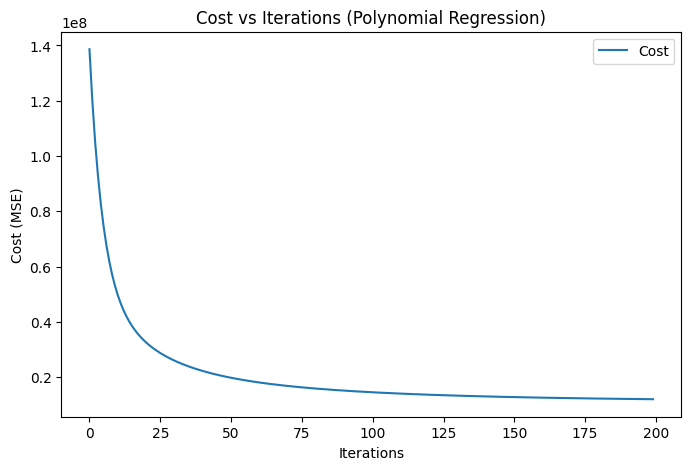

In [80]:
# --------------------
# 10. Plot Cost vs Iterations
# --------------------
plt.figure(figsize=(8,5))
plt.plot(range(num_iters), cost_history, label="Cost")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs Iterations (Polynomial Regression)")
plt.legend()
plt.show()

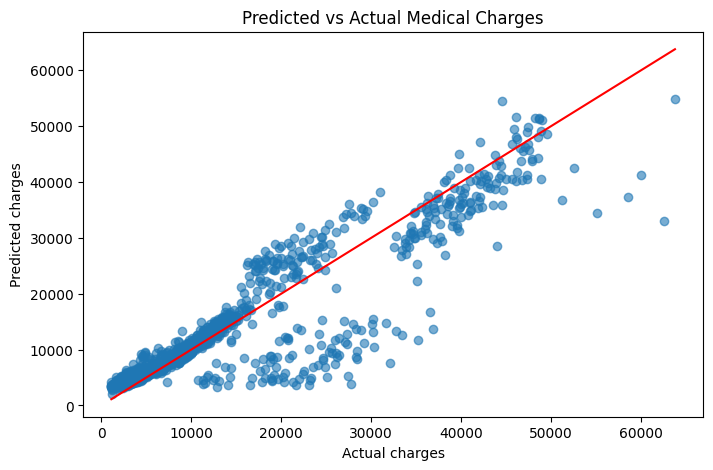

In [81]:
# --------------------
# 11. Predicted vs Actual
# --------------------
y_pred = X_poly.dot(w) + b
plt.figure(figsize=(8,5))
plt.scatter(y, y_pred, alpha=0.6)
plt.xlabel("Actual charges")
plt.ylabel("Predicted charges")
plt.title("Predicted vs Actual Medical Charges")
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r')
plt.show()